In [4]:
from openai import OpenAI

In [5]:
client = OpenAI(
    base_url="https://inference.hetzner.com/api/v1",
    api_key="qNFpw3IxhiKjg4CsjHf_5GJHOpVKncZ5"
)

In [14]:
from pathlib import Path

book = Path("data/book.txt").read_text()

In [15]:
book

'The Project Gutenberg eBook of Twenty Thousand Leagues under the Sea\n\nThis eBook is for the use of anyone anywhere in the United States and\nmost other parts of the world at no cost and with almost no restrictions\nwhatsoever. You may copy it, give it away or re-use it under the terms\nof the Project Gutenberg License included with this eBook or online\nat www.gutenberg.org. If you are not located in the United States,\nyou will have to check the laws of the country where you are located\nbefore using this eBook.\n\nTitle: Twenty Thousand Leagues under the Sea\n\nAuthor: Jules Verne\n\n\n\nRelease date: September 1, 1994 [eBook #164]\n                Most recently updated: March 18, 2025\n\nLanguage: English\n\nOther information and formats: www.gutenberg.org/ebooks/164\n\nCredits: a number of anonymous Gutenberg Project volunteers\n\n\n*** START OF THE PROJECT GUTENBERG EBOOK TWENTY THOUSAND LEAGUES UNDER THE SEA ***\n\n\n\n\nTwenty Thousand Leagues under the Sea\n\nby Jules Verne\

In [16]:
model = "Qwen/Qwen3.6-35B-A3B-FP8"

import time


start = time.time()
resp = client.chat.completions.create(
    model=model,
    messages=[
        {
            "role": "user",
            "content": \
                "There is a missing paragraph in the book below. One of these "
                "paragraphs has been cut off partially through mid sentence. "
                "I need you to identify that paragraph in this "
                "book and complete that paragraph as if it was "
                "written in the original manuscript. Output the chapter "
                "of the paragraph and the completed version that you generate.\n"
                f"<book>{book}</book>"
        }
    ]
)
elapsed_seconds = time.time()- start

In [18]:
print(resp.choices[0].message.content)



**Chapter:** XIII

**Completed Paragraph:** 
During the geological epochs, the igneous period succeeded to the aqeous. The ocean originally prevailed everywhere. Then by degrees, in the silurian period, the tops of the mountains began to appear, the islands emerged, then disappeared beneath the waters.


In [19]:
import requests

target_url = "https://picsum.photos/seed/{seed}/1024/768"

page = requests.get(target_url.format(seed=21381273))



In [30]:
import base64

image_bytes = page.content

base64_img = base64.b64encode(image_bytes).decode("utf-8")
image_data_uri = f"data:image/jpeg;base64,{base64_img}"

prompt = "What is in this photo? Describe it in detail. Keep the thinking short."

response = client.chat.completions.create(
    model=model,
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": image_data_uri}},
            ],
        }
    ],
    max_tokens=6000,
)



In [33]:
print(response.to_json())


{
  "id": "chatcmpl-ef4f2926-cdbc-433c-a141-e86b8477400e",
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "logprobs": null,
      "message": {
        "content": "\n\nThis photo displays a close-up view of a rustic wooden surface, likely a floor or paneled wall, constructed from horizontal planks. The wood features a warm, rich palette of amber, honey, and reddish-brown tones.\n\nDetailed features include:\n*   **Wood Grain and Texture:** The planks show distinct natural wood grain running horizontally across the frame. There are several knots visible as dark, circular swirls within the wood.\n*   **Imperfections and Stains:** The surface is visibly aged and worn. Near the bottom third, there is a large, dark, irregular patch that resembles a burn mark or a heavy spill.\n*   **Footprints:** Below that dark patch, on the lower plank, there are distinct imprints that look like shoe treads or boot prints, suggesting the floor was walked on with dirty shoes. Th

In [31]:
print(response.choices[0].message.content)



This photo displays a close-up view of a rustic wooden surface, likely a floor or paneled wall, constructed from horizontal planks. The wood features a warm, rich palette of amber, honey, and reddish-brown tones.

Detailed features include:
*   **Wood Grain and Texture:** The planks show distinct natural wood grain running horizontally across the frame. There are several knots visible as dark, circular swirls within the wood.
*   **Imperfections and Stains:** The surface is visibly aged and worn. Near the bottom third, there is a large, dark, irregular patch that resembles a burn mark or a heavy spill.
*   **Footprints:** Below that dark patch, on the lower plank, there are distinct imprints that look like shoe treads or boot prints, suggesting the floor was walked on with dirty shoes. There are also fainter scuff marks in the bottom left corner.
*   **Lighting:** The image has a slightly vintage aesthetic, with the corners appearing darker (vignetting) than the center.


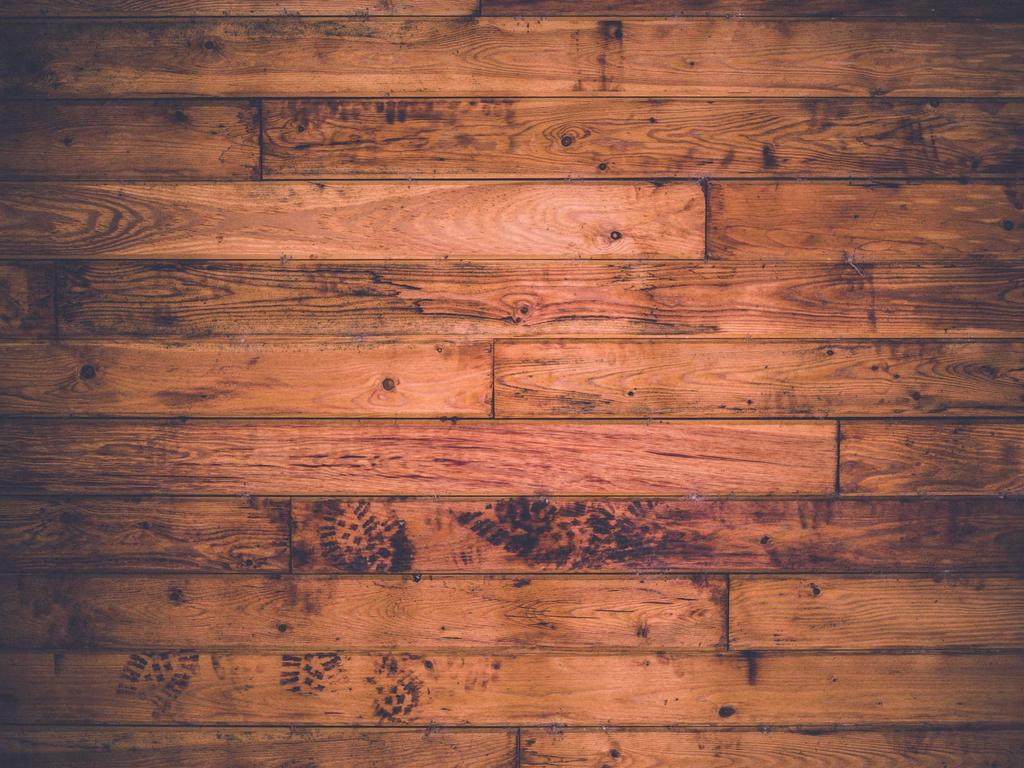

In [32]:
from IPython.display import display, Image

display(Image(page.content))